# L3.3 — Backpropagation

Hands-on notebook for the lesson [`3-3-backprop.mdx`](../../llm-quest-theory/level-3/3-3-backprop.mdx).

> **Learning objectives**
> - Write the forward pass and the backward pass of a 2-layer MLP entirely by hand in NumPy.
> - Verify every gradient against `torch.autograd` to atomic precision.
> - See the elegant result `delta^(L) = y_hat - y` when softmax is paired with cross-entropy.
> - Feel the vanishing-gradient problem on a deep sigmoid stack.

## Connection to the theory
Covers **§1–§6** of the source `.mdx`. This is the lesson that turns autograd from magic into a concrete algorithm you could re-implement.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Architecture we will differentiate

```
x  (B x d_in)
 -> z1 = x W1^T + b1    (linear)
 -> h1 = ReLU(z1)        (activation)
 -> z2 = h1 W2^T + b2   (linear)
 -> p  = softmax(z2)     (probabilities)
Loss = CrossEntropy(p, y)
```

Shapes: `W1: (h, d_in)`, `b1: (h,)`, `W2: (C, h)`, `b2: (C,)`.
We use the batch convention of Level 2: each row of `x` is one sample.

In [2]:
B, d_in, h, C = 5, 4, 3, 2  # small enough to print
rng = np.random.default_rng(SEED)

x   = rng.normal(size=(B, d_in))
y   = rng.integers(0, C, size=B)         # integer class labels

W1  = rng.normal(size=(h, d_in)) * 0.5
b1  = np.zeros(h)
W2  = rng.normal(size=(C, h))    * 0.5
b2  = np.zeros(C)

print("x:", x.shape, "  y:", y.shape, "  W1:", W1.shape, "  W2:", W2.shape)

x: (5, 4)   y: (5,)   W1: (3, 4)   W2: (2, 3)


## 2. Forward pass — NumPy
Cache the intermediate tensors we will need for the backward pass.

In [3]:
def softmax(z, axis=-1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)

def forward(x, W1, b1, W2, b2, y):
    z1 = x @ W1.T + b1
    h1 = np.maximum(0.0, z1)                              # ReLU
    z2 = h1 @ W2.T + b2
    p  = softmax(z2, axis=1)                              # (B, C)
    # Cross-entropy, averaged over the batch
    log_p_true = np.log(p[np.arange(len(y)), y] + 1e-12)
    loss = float(-log_p_true.mean())
    cache = (x, z1, h1, z2, p, y)
    return loss, cache

loss_np, cache = forward(x, W1, b1, W2, b2, y)
print(f"NumPy forward loss: {loss_np:.6f}")

NumPy forward loss: 0.685780


## 3. Backward pass — NumPy

$$\delta^{(2)} = \mathbf{p} - \mathbf{y}_{\text{one-hot}} \qquad\text{(softmax + cross-entropy shortcut)}$$

$$\frac{\partial L}{\partial W^{(2)}} = \frac{1}{B}\,{\delta^{(2)}}^\top \mathbf{h}^{(1)} \qquad \frac{\partial L}{\partial \mathbf{b}^{(2)}} = \frac{1}{B}\sum_b \delta^{(2)}_b$$

$$\delta^{(1)} = \big(\delta^{(2)} W^{(2)}\big) \odot \mathbb{1}[z^{(1)} > 0]$$

$$\frac{\partial L}{\partial W^{(1)}} = \frac{1}{B}\,{\delta^{(1)}}^\top \mathbf{x}\qquad \frac{\partial L}{\partial \mathbf{b}^{(1)}} = \frac{1}{B}\sum_b \delta^{(1)}_b$$

In [4]:
def backward(cache, W2):
    x, z1, h1, z2, p, y = cache
    B = len(y)

    # One-hot targets
    y_oh = np.zeros_like(p)
    y_oh[np.arange(B), y] = 1.0

    # Output-layer delta: softmax + CE collapses to (p - y_oh) / B
    delta2 = (p - y_oh) / B

    dW2 = delta2.T @ h1
    db2 = delta2.sum(axis=0)

    # Backprop through the hidden layer
    dh1 = delta2 @ W2
    delta1 = dh1 * (z1 > 0)   # ReLU derivative

    dW1 = delta1.T @ x
    db1 = delta1.sum(axis=0)
    return dW1, db1, dW2, db2

dW1_np, db1_np, dW2_np, db2_np = backward(cache, W2)
print("dW1.shape:", dW1_np.shape, "  dW2.shape:", dW2_np.shape)

dW1.shape: (3, 4)   dW2.shape: (2, 3)


## 4. Cross-check with `torch.autograd`
Same inputs, same weights, autograd should give the same gradients to floating-point precision.

In [5]:
x_t  = torch.tensor(x,  dtype=torch.float64)
y_t  = torch.tensor(y,  dtype=torch.long)
W1_t = torch.tensor(W1, dtype=torch.float64, requires_grad=True)
b1_t = torch.tensor(b1, dtype=torch.float64, requires_grad=True)
W2_t = torch.tensor(W2, dtype=torch.float64, requires_grad=True)
b2_t = torch.tensor(b2, dtype=torch.float64, requires_grad=True)

z1_t = x_t @ W1_t.T + b1_t
h1_t = torch.relu(z1_t)
z2_t = h1_t @ W2_t.T + b2_t
loss_t = nn.functional.cross_entropy(z2_t, y_t)    # expects logits
loss_t.backward()

print(f"torch forward loss: {loss_t.item():.6f}")
print(f"NumPy forward loss: {loss_np:.6f}")
print("Losses match?     :", np.isclose(loss_t.item(), loss_np))

for name, np_grad, torch_grad in [
    ("dW1", dW1_np, W1_t.grad.numpy()),
    ("db1", db1_np, b1_t.grad.numpy()),
    ("dW2", dW2_np, W2_t.grad.numpy()),
    ("db2", db2_np, b2_t.grad.numpy()),
]:
    max_diff = float(np.max(np.abs(np_grad - torch_grad)))
    print(f"{name}: max |numpy - torch| = {max_diff:.2e}")

torch forward loss: 0.685780
NumPy forward loss: 0.685780
Losses match?     : True
dW1: max |numpy - torch| = 5.55e-17
db1: max |numpy - torch| = 2.78e-17
dW2: max |numpy - torch| = 1.39e-17
db2: max |numpy - torch| = 2.78e-17


## 5. Gradient check via finite differences
Independent of autograd: perturb each weight by `eps` and approximate the derivative. Must agree with our analytic `dW1, dW2`.

In [6]:
def loss_at(W1, b1, W2, b2):
    L, _ = forward(x, W1, b1, W2, b2, y)
    return L

def finite_diff_grad_W(W, loss_fn_of_W, eps=1e-6):
    g = np.zeros_like(W)
    it = np.nditer(W, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        orig = W[idx]
        W[idx] = orig + eps; lp = loss_fn_of_W(W)
        W[idx] = orig - eps; lm = loss_fn_of_W(W)
        W[idx] = orig
        g[idx] = (lp - lm) / (2 * eps)
        it.iternext()
    return g

dW1_fd = finite_diff_grad_W(W1.copy(), lambda W: loss_at(W, b1, W2, b2))
dW2_fd = finite_diff_grad_W(W2.copy(), lambda W: loss_at(W1, b1, W, b2))

print(f"dW1 max |analytic - fd| = {np.max(np.abs(dW1_np - dW1_fd)):.2e}")
print(f"dW2 max |analytic - fd| = {np.max(np.abs(dW2_np - dW2_fd)):.2e}")

dW1 max |analytic - fd| = 7.12e-11
dW2 max |analytic - fd| = 4.77e-11


## 6. The vanishing gradient problem
Build a stack of `L` sigmoid layers, pump in a random input, and watch the norm of the gradient at the input shrink with depth.

In [7]:
def deep_grad_norm(depth, activation="sigmoid", d=50, n_samples=32):
    torch.manual_seed(SEED)
    layers = []
    for _ in range(depth):
        layers.append(nn.Linear(d, d))
        if activation == "sigmoid":
            layers.append(nn.Sigmoid())
        elif activation == "relu":
            layers.append(nn.ReLU())
    net = nn.Sequential(*layers)
    x0 = torch.randn(n_samples, d, requires_grad=True)
    out = net(x0).sum()
    out.backward()
    return float(x0.grad.norm())

depths = [1, 2, 5, 10, 20, 30]
sig_norms  = [deep_grad_norm(d, "sigmoid") for d in depths]
relu_norms = [deep_grad_norm(d, "relu")    for d in depths]

for d, s, r in zip(depths, sig_norms, relu_norms):
    print(f"depth {d:>2}: sigmoid |grad x| = {s:.2e}    ReLU |grad x| = {r:.2e}")

depth  1: sigmoid |grad x| = 4.85e+00    ReLU |grad x| = 1.76e+01
depth  2: sigmoid |grad x| = 9.15e-01    ReLU |grad x| = 9.97e+00
depth  5: sigmoid |grad x| = 2.51e-03    ReLU |grad x| = 5.71e-01
depth 10: sigmoid |grad x| = 1.82e-07    ReLU |grad x| = 1.73e-03
depth 20: sigmoid |grad x| = 2.67e-16    ReLU |grad x| = 6.43e-07
depth 30: sigmoid |grad x| = 0.00e+00    ReLU |grad x| = 1.72e-10


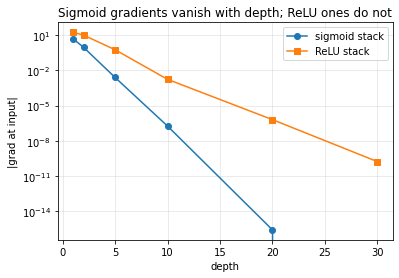

In [8]:
fig, ax = plt.subplots()
ax.plot(depths, sig_norms,  "o-", label="sigmoid stack")
ax.plot(depths, relu_norms, "s-", label="ReLU stack")
ax.set_xlabel("depth"); ax.set_ylabel("|grad at input|")
ax.set_yscale("log"); ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set_title("Sigmoid gradients vanish with depth; ReLU ones do not")
plt.show()

## 7. Quick checks

In [9]:
assert np.isclose(loss_t.item(), loss_np)
assert np.max(np.abs(dW1_np - W1_t.grad.numpy())) < 1e-10
assert np.max(np.abs(dW2_np - W2_t.grad.numpy())) < 1e-10
assert np.max(np.abs(dW1_np - dW1_fd)) < 1e-5, "analytic must match finite differences"
# Sigmoid stack must lose at least 10x gradient between depth 1 and 30
# Use log10 ratio to stay robust when the deep gradient underflows to ~0.
ratio = sig_norms[0] / (sig_norms[-1] + 1e-30)
assert ratio > 10, f"sigmoid gradients must vanish noticeably with depth (ratio={ratio:.2e})"
assert relu_norms[-1] > sig_norms[-1], "ReLU should keep more gradient than sigmoid at depth 30"
print("OK — our backprop matches torch.autograd to 1e-10 and finite differences to 1e-5.")

OK — our backprop matches torch.autograd to 1e-10 and finite differences to 1e-5.


## Reflection questions

1. The derivation `delta = p - y_oh` is only that clean because softmax + cross-entropy are paired. What does `delta` look like if the loss is MSE on the softmax output instead?
2. Our analytic and finite-difference gradients agreed to ~1e-5, but autograd matched to ~1e-10. Why the gap?
3. Looking at section 6, what happens if we swap `nn.Sigmoid()` for `nn.Tanh()` — same, better, or worse?
4. Residual connections (`h_{l+1} = h_l + f(h_l)`) are said to "help gradients flow." Implement a 20-layer ResNet-style stack and compare its `|grad at input|` against the plain ReLU stack.

## References
- Source theory: [`3-3-backprop.mdx`](../../llm-quest-theory/level-3/3-3-backprop.mdx)
- Next: [`3-4-regularization`](3-4-regularization.ipynb)